# 📊 Análisis de Métricas y KPIs en Python


In [2]:
# 1. Carga de librerías y datos de la base de datos relacional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Carga de datasets
df_cliente = pd.read_csv('../../contenidos/DataFrames/db_cliente.csv')
df_lote = pd.read_csv('../../contenidos/DataFrames/db_lote.csv')
df_marca = pd.read_csv('../../contenidos/DataFrames/db_marca.csv')
df_producto = pd.read_csv('../../contenidos/DataFrames/db_producto.csv', low_memory=False)
df_proveedores = pd.read_csv('../../contenidos/DataFrames/db_proveedores.csv')
df_subtipo = pd.read_csv('../../contenidos/DataFrames/db_subtipo.csv')
df_tipo = pd.read_csv('../../contenidos/DataFrames/db_tipo.csv')
df_venta = pd.read_csv('../../contenidos/DataFrames/db_venta.csv')

# Merge consolidado para transacciones de venta completas
df_venta_m = df_venta.merge(df_cliente, left_on='id_cliente', right_on='id', suffixes=('', '_cliente'))
df_venta_m = df_venta_m.merge(df_producto, left_on='id_producto', right_on='id', suffixes=('', '_producto'))
df_venta_m = df_venta_m.merge(df_proveedores, left_on='id_proveedor', right_on='id', suffixes=('', '_proveedor'))
df_venta_m = df_venta_m.merge(df_tipo, left_on='id_tipo', right_on='id', suffixes=('', '_tipo'))

df_venta_m['tiempo_venta_dt'] = pd.to_datetime(df_venta_m['tiempo_venta'])
df_venta_m['fecha_venta'] = df_venta_m['tiempo_venta_dt'].dt.date
df_producto['tiempo_recogida_dt'] = pd.to_datetime(df_producto['tiempo_recogida'])

print("✅ Datos cargados y consolidados correctamente.")

✅ Datos cargados y consolidados correctamente.


---

### 1 - 2 
- 1. Calcular la media diaria de la cuantía de las distribuciones
- 2. Calcular la cuantía total de las distribuciones

In [18]:
cuantia_total = df_venta_m['precio_venta'].sum()
media_diaria = df_venta_m.groupby('fecha_venta')['precio_venta'].sum().mean()

print(f"Cuantía Total de Distribuciones: {cuantia_total:,.2f} €")
print(f"Media Diaria de la Cuantía: {media_diaria:,.2f} €/día")

Cuantía Total de Distribuciones: 244,374.64 €
Media Diaria de la Cuantía: 7,612.43 €/día


---

### 3. ¿Qué días del mes se han producido más distribuciones y cuántas?

Top 5 días con más distribuciones:


,fecha_venta,num_distribuciones
13,2025-09-13,2398
14,2025-09-14,2388
18,2025-09-18,2374
29,2025-09-29,2371
3,2025-09-03,2362


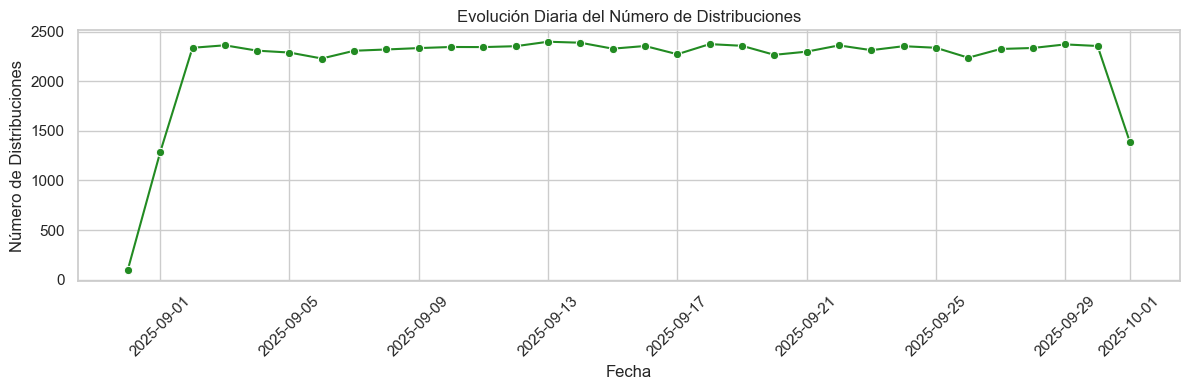

In [19]:
dist_por_dia = df_venta_m.groupby('fecha_venta').size().reset_index(name='num_distribuciones')
dist_por_dia = dist_por_dia.sort_values(by='num_distribuciones', ascending=False)

print("Top 5 días con más distribuciones:")
display(dist_por_dia.head(5))

# Gráfico de líneas de distribuciones diarias
plt.figure(figsize=(12, 4))
sns.lineplot(data=dist_por_dia.sort_values('fecha_venta'), x='fecha_venta', y='num_distribuciones', marker='o', color='forestgreen')
plt.title('Evolución Diaria del Número de Distribuciones')
plt.xlabel('Fecha')
plt.ylabel('Número de Distribuciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

### 4. ¿A qué horas del día se producen más recogidas de alimentos y cuántas?

C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\843470011.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recogidas_hora, x='hora', y='num_recogidas', palette='Blues_d')


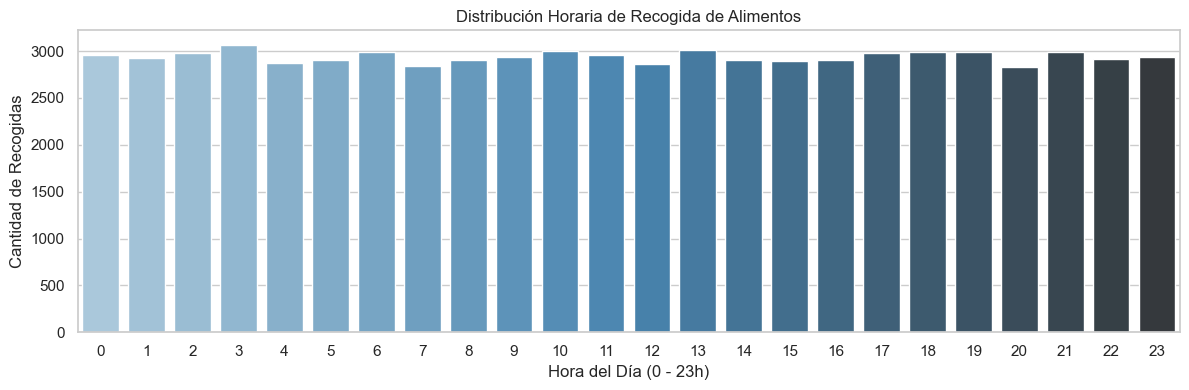

Horas pico de recogida:


,hora,num_recogidas
0,3,3067
1,13,3007
2,10,3002
3,19,2995
4,6,2990


In [20]:
df_producto['hora_recogida'] = df_producto['tiempo_recogida_dt'].dt.hour
recogidas_hora = df_producto['hora_recogida'].value_counts().reset_index()
recogidas_hora.columns = ['hora', 'num_recogidas']
recogidas_hora = recogidas_hora.sort_values('hora')

# Gráfico de barras por hora
plt.figure(figsize=(12, 4))
sns.barplot(data=recogidas_hora, x='hora', y='num_recogidas', palette='Blues_d')
plt.title('Distribución Horaria de Recogida de Alimentos')
plt.xlabel('Hora del Día (0 - 23h)')
plt.ylabel('Cantidad de Recogidas')
plt.tight_layout()
plt.show()

print("Horas pico de recogida:")
display(recogidas_hora.sort_values('num_recogidas', ascending=False).head(5))

---

### 5 - 6
- 5. ¿Cuáles son los 5 clientes que más dinero han gastado comprando la fruta y cuánto?
- 6. ¿Cuáles son los 5 clientes que menos dinero han gastado comprando la fruta y cuánto?

C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\1791521898.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_clientes, x='precio_venta', y='nombre', ax=axes[0], palette='Greens_r')
C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\1791521898.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom5_clientes, x='precio_venta', y='nombre', ax=axes[1], palette='Oranges')


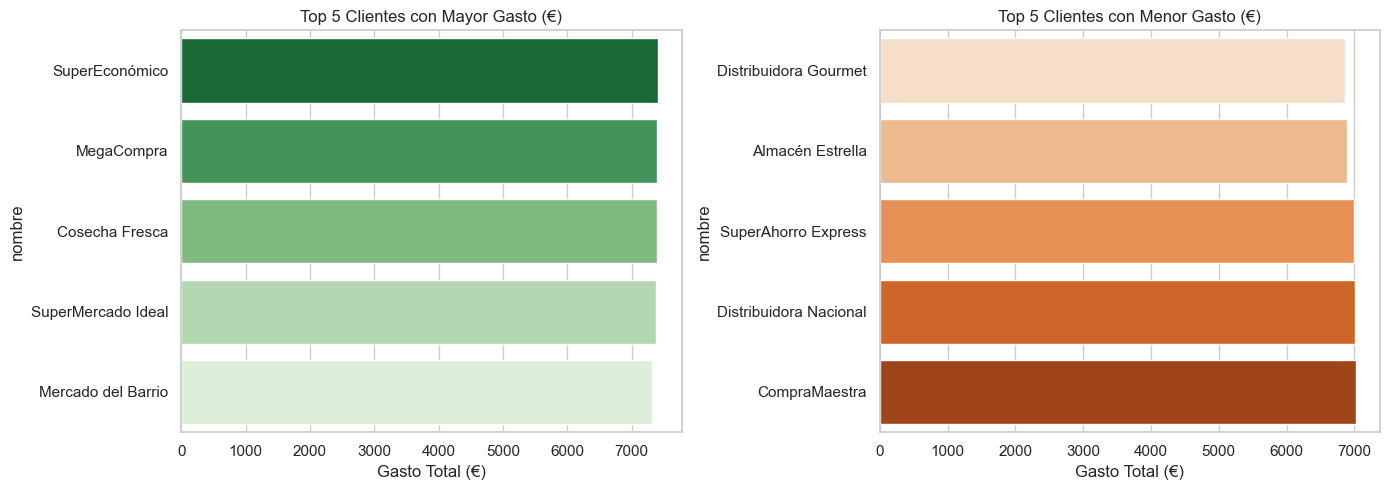

Top 5 Clientes con Mayor Gasto:


,nombre,precio_venta
27,SuperEconómico,7403.354381
23,MegaCompra,7393.950740
7,Cosecha Fresca,7387.147370
28,SuperMercado Ideal,7376.697472
25,Mercado del Barrio,7308.904167


Top 5 Clientes con Menor Gasto:


,nombre,precio_venta
11,Distribuidora Gourmet,6866.818337
2,Almacén Estrella,6892.032101
26,SuperAhorro Express,6992.419539
12,Distribuidora Nacional,7012.784912
5,CompraMaestra,7026.490665


In [21]:
gasto_clientes = df_venta_m.groupby('nombre')['precio_venta'].sum().reset_index()
top5_clientes = gasto_clientes.nlargest(5, 'precio_venta')
bottom5_clientes = gasto_clientes.nsmallest(5, 'precio_venta')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top5_clientes, x='precio_venta', y='nombre', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 5 Clientes con Mayor Gasto (€)')
axes[0].set_xlabel('Gasto Total (€)')

sns.barplot(data=bottom5_clientes, x='precio_venta', y='nombre', ax=axes[1], palette='Oranges')
axes[1].set_title('Top 5 Clientes con Menor Gasto (€)')
axes[1].set_xlabel('Gasto Total (€)')

plt.tight_layout()
plt.show()

print("Top 5 Clientes con Mayor Gasto:")
display(top5_clientes)
print("Top 5 Clientes con Menor Gasto:")
display(bottom5_clientes)

---

### 7. ¿Cuáles son los 10 proveedores que han recibido más dinero y cuánto?

C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\500623031.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_proveedores, x='coste_inicial', y='nombre_proveedor', palette='Purples_r')


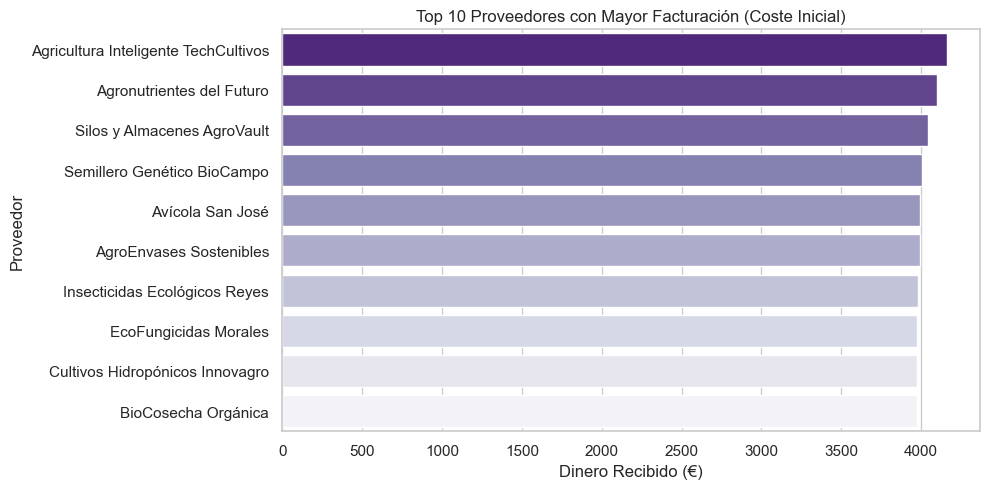

,nombre_proveedor,coste_inicial
0,Agricultura Inteligente TechCultivos,4159.933578
1,Agronutrientes del Futuro,4097.708206
2,Silos y Almacenes AgroVault,4040.688387
3,Semillero Genético BioCampo,4005.312537
4,Avícola San José,3995.049718
5,AgroEnvases Sostenibles,3993.864433
6,Insecticidas Ecológicos Reyes,3982.551810
7,EcoFungicidas Morales,3975.794924
8,Cultivos Hidropónicos Innovagro,3975.578027
9,BioCosecha Orgánica,3973.008504


In [9]:
top10_proveedores = df_venta_m.groupby('nombre_proveedor')['coste_inicial'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_proveedores, x='coste_inicial', y='nombre_proveedor', palette='Purples_r')
plt.title('Top 10 Proveedores con Mayor Facturación (Coste Inicial)')
plt.xlabel('Dinero Recibido (€)')
plt.ylabel('Proveedor')
plt.tight_layout()
plt.show()

display(top10_proveedores)

---

### 8, 9 y 14
- 8. ¿Cuáles son los 3 productos con mayor beneficio a lo largo del mes (aquellos que al restarle al coste de venta el precio de compra se quedan con un mejor resultado) y cuál ha sido su balance? 
- 9. ¿Cuáles son los 3 productos con peor beneficio a lo largo de todo el mes y cuál ha sido?
- 14. Para cada producto, calcular el porcentaje de beneficio.

In [22]:
# 8, 9 & 14. Beneficio y Porcentaje de Beneficio AGRUPADO POR TIPO DE FRUTA

# Agrupación por tipo de fruta sumando costes e ingresos
df_beneficio_tipo = (
    df_venta_m.groupby("nombre_tipo")[["coste_inicial", "precio_venta"]]
    .sum()
    .reset_index()
)
df_beneficio_tipo.rename(
    columns={"coste_inicial": "coste_total", "precio_venta": "venta_total"},
    inplace=True,
)

# Beneficio total y % de beneficio acumulado por tipo de fruta
df_beneficio_tipo["beneficio_total"] = (
    df_beneficio_tipo["venta_total"] - df_beneficio_tipo["coste_total"]
)
df_beneficio_tipo["pct_beneficio"] = (
    df_beneficio_tipo["beneficio_total"] / df_beneficio_tipo["coste_total"]
) * 100

# Top 3 tipos de fruta con mayor y peor beneficio total
top3_tipos = df_beneficio_tipo.nlargest(3, "beneficio_total")
bottom3_tipos = df_beneficio_tipo.nsmallest(3, "beneficio_total")

print("Top 3 TIPOS DE FRUTA con MAYOR Beneficio Total:")
display(top3_tipos)

print("\nTop 3 TIPOS DE FRUTA con PEOR Beneficio Total:")
display(bottom3_tipos)

print("\nResumen Completo de Beneficio y Porcentaje por Tipo de Fruta:")
display(
    df_beneficio_tipo.sort_values(
        by="beneficio_total", ascending=False
    ).reset_index(drop=True)
)

Top 3 TIPOS DE FRUTA con MAYOR Beneficio Total:


,nombre_tipo,coste_total,venta_total,beneficio_total,pct_beneficio
3,Guava,38335.690819,68237.296941,29901.606122,77.999393
0,Apple,21692.662073,38618.001662,16925.339589,78.023340
4,Kiwi,16506.398593,29412.542589,12906.143996,78.188733



Top 3 TIPOS DE FRUTA con PEOR Beneficio Total:


,nombre_tipo,coste_total,venta_total,beneficio_total,pct_beneficio
2,Carambola,4032.107981,7167.771499,3135.663518,77.767350
14,muskmelon,4015.519270,7161.612667,3146.093397,78.348358
9,Persimmon,3992.802333,7196.936022,3204.133690,80.247741



Resumen Completo de Beneficio y Porcentaje por Tipo de Fruta:


,nombre_tipo,coste_total,venta_total,beneficio_total,pct_beneficio
0,Guava,38335.690819,68237.296941,29901.606122,77.999393
1,Apple,21692.662073,38618.001662,16925.339589,78.023340
2,Kiwi,16506.398593,29412.542589,12906.143996,78.188733
3,Mango,8092.343353,14380.994254,6288.650901,77.711123
4,Orange,5863.319222,10532.255315,4668.936093,79.629574
5,Pear,5820.072310,10444.245029,4624.172719,79.452152
6,Banana,5869.840813,10452.832928,4582.992115,78.076940
7,Peach,5123.813862,9168.104892,4044.291030,78.931264
8,Pitaya,4836.496660,8710.536151,3874.039491,80.100117
9,Plum,4492.465516,7931.971499,3439.505983,76.561656


---

### 10. ¿Cuál es el precio de venta medio de cada fruta?

C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\1635444291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=precio_medio_fruta, x='precio_venta', y='nombre_tipo', palette='Spectral')


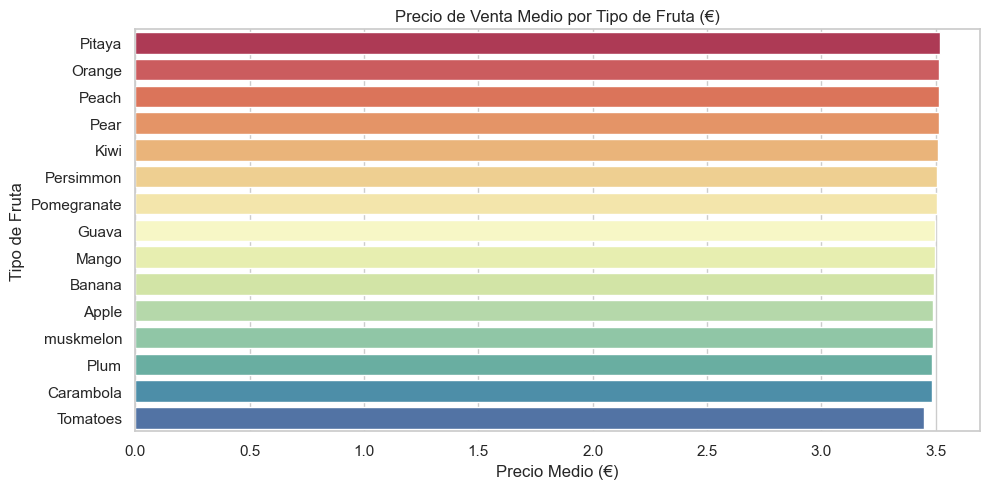

,nombre_tipo,precio_venta
10,Pitaya,3.517987
6,Orange,3.515439
7,Peach,3.515378
8,Pear,3.514214
4,Kiwi,3.509850
9,Persimmon,3.505570
12,Pomegranate,3.504110
3,Guava,3.498990
5,Mango,3.497324
1,Banana,3.493594


In [11]:
precio_medio_fruta = df_venta_m.groupby('nombre_tipo')['precio_venta'].mean().reset_index()
precio_medio_fruta = precio_medio_fruta.sort_values('precio_venta', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=precio_medio_fruta, x='precio_venta', y='nombre_tipo', palette='Spectral')
plt.title('Precio de Venta Medio por Tipo de Fruta (€)')
plt.xlabel('Precio Medio (€)')
plt.ylabel('Tipo de Fruta')
plt.tight_layout()
plt.show()

display(precio_medio_fruta)

---

### 11 y 12
- 11. Suponiendo que si no se dispone de información de venta se trata de una fruta que no ha podido venderse por haber sido dañada durante la distribución, ¿cuánta fruta de cada tipo ha sido dañada?
- 12. ¿Cuál ha sido la pérdida total de la fruta dañada?

C:\Users\jaime\AppData\Local\Temp\ipykernel_32056\1352519221.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fruta_danada_tipo, x='cantidad_danada', y='tipo_fruta', palette='Reds_r')


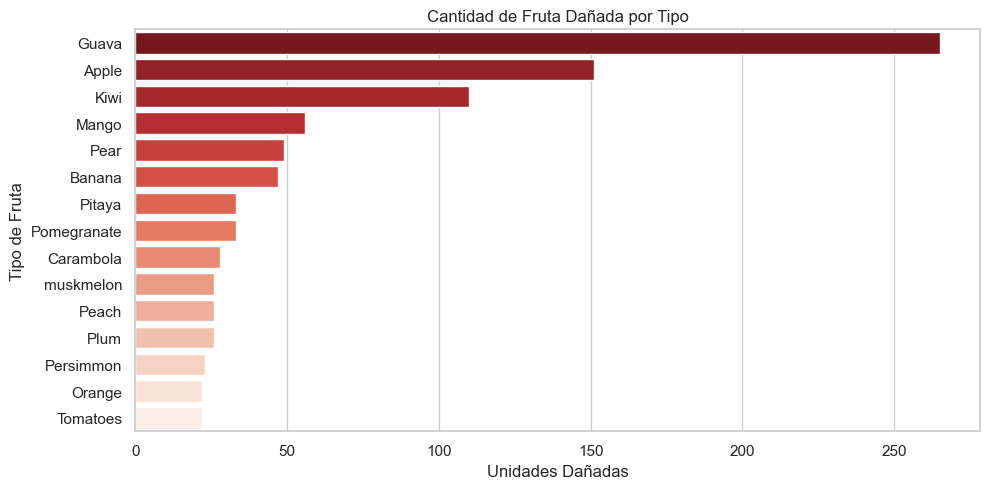

Pérdida Total por Fruta Dañada: 1,788.80 €


,tipo_fruta,cantidad_danada
0,Guava,265
1,Apple,151
2,Kiwi,110
3,Mango,56
4,Pear,49
5,Banana,47
6,Pitaya,33
7,Pomegranate,33
8,Carambola,28
9,muskmelon,26


In [23]:
df_venta_danada = df_venta[df_venta['precio_venta'].isna() | df_venta['tiempo_venta'].isna()].copy()
df_venta_danada = df_venta_danada.merge(df_producto, left_on='id_producto', right_on='id', suffixes=('', '_prod'))
df_venta_danada = df_venta_danada.merge(df_tipo, left_on='id_tipo', right_on='id', suffixes=('', '_tipo'))

fruta_danada_tipo = df_venta_danada['nombre'].value_counts().reset_index()
fruta_danada_tipo.columns = ['tipo_fruta', 'cantidad_danada']

perdida_total = df_venta_danada['coste_inicial'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(data=fruta_danada_tipo, x='cantidad_danada', y='tipo_fruta', palette='Reds_r')
plt.title('Cantidad de Fruta Dañada por Tipo')
plt.xlabel('Unidades Dañadas')
plt.ylabel('Tipo de Fruta')
plt.tight_layout()
plt.show()

print(f"Pérdida Total por Fruta Dañada: {perdida_total:,.2f} €")
display(fruta_danada_tipo)

---

### 13. ¿Cuál es la cuantía total de cada tipo de fruta que han comprado los 5 clientes que más dinero han gastado?

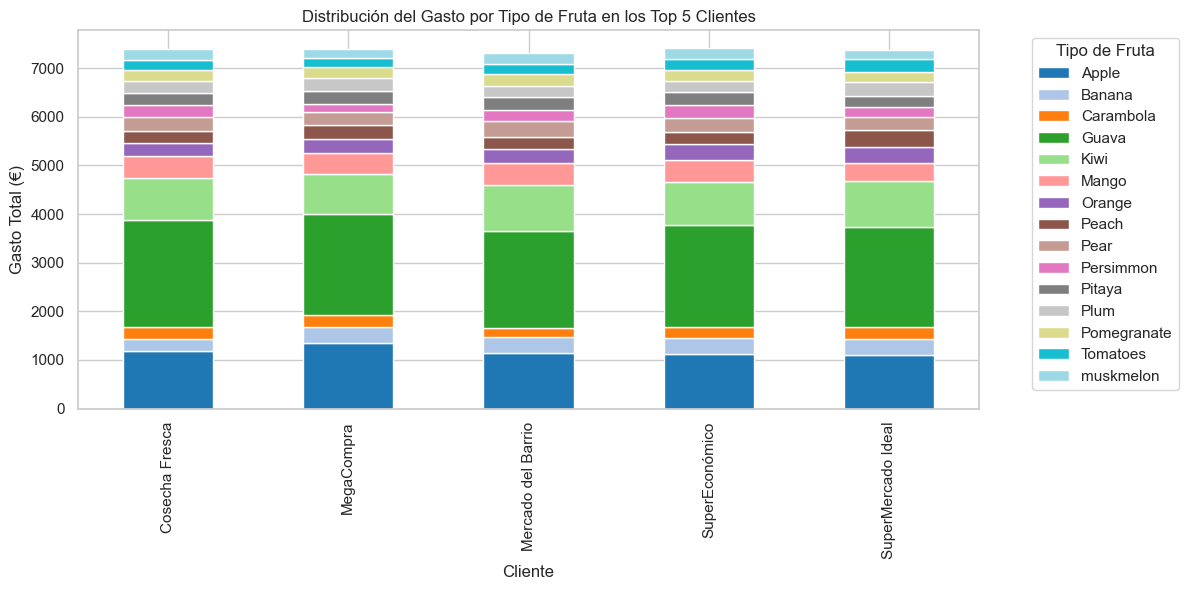

nombre_tipo,Apple,Banana,Carambola,Guava,Kiwi,Mango,Orange,Peach,Pear,Persimmon,Pitaya,Plum,Pomegranate,Tomatoes,muskmelon
nombre,,,,,,,,,,,,,,,
Cosecha Fresca,1175.504435,258.847333,244.566639,2207.792471,844.729539,467.205214,270.991340,240.875265,289.475067,242.885511,239.645990,260.239984,225.765284,201.554557,217.068740
MegaCompra,1348.258393,328.791394,245.226170,2085.251791,805.558163,440.157716,286.162102,292.643291,269.765861,161.340242,259.721823,268.928654,226.108060,195.298259,180.738822
Mercado del Barrio,1133.178624,339.341666,178.956777,2002.073112,951.691208,440.582382,296.652233,239.724039,321.158912,225.187947,274.766863,231.243881,247.972666,197.588829,228.785028
SuperEconómico,1131.283252,324.293841,231.209108,2093.330072,883.476573,436.766397,334.083933,242.520995,289.340000,271.121178,265.691749,221.462164,241.597302,216.650551,220.527264
SuperMercado Ideal,1096.827360,331.215186,240.977540,2062.250919,945.370378,380.744698,318.637602,344.473858,270.160771,203.887171,237.536380,275.654578,219.222980,253.933420,195.804630


In [14]:
top5_nombres = top5_clientes['nombre'].tolist()
df_top5_ventas = df_venta_m[df_venta_m['nombre'].isin(top5_nombres)]

pivot_top5 = df_top5_ventas.groupby(['nombre', 'nombre_tipo'])['precio_venta'].sum().unstack(fill_value=0)

# Gráfico de barras apiladas
pivot_top5.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Distribución del Gasto por Tipo de Fruta en los Top 5 Clientes')
plt.xlabel('Cliente')
plt.ylabel('Gasto Total (€)')
plt.legend(title='Tipo de Fruta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(pivot_top5)